# Prerequisities
In this section we install all necerssary libraries and and import them. Additionally, we also set up the config to use for the training later on.

## Installation Block

In [2]:
#Install block based on HuggingFace
%pip install datasets
%pip install diffusers
%pip install Pillow
%pip install PIL
%pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 torchaudio==2.0.2+cu117 --extra-index-url https://download.pytorch.org/whl/cu117 --no-cache-dir --user
%pip uninstall numpy
%pip install numpy==1.26.4
%pip install accelerate
%pip install matplotlib
%pip install torch_ema

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Block

In [11]:
import torch
from datasets import load_dataset
import torchvision
import PIL
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from dataclasses import dataclass
import torch_ema
from torch.nn.functional import relu
from torch.optim import AdamW
import visualisation

## Training Configuration

In [12]:
@dataclass
class TrainingConfig:
    image_size = 28  # the generated image resolution - 28px to fit the original images
    train_batch_size = 64
    eval_batch_size = 64  # how many images to sample during evaluation
    num_epochs = 19
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmup_steps = 500
    save_image_epochs = 1
    mixed_precision='fp16' 
    device_placement=True
    data_output_dir = "./data/"
    model_output_dir = "./models/"  # the model name locally and on the HF Hub
    visualisation_output_dir = "./visualisation/"
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0
    num_inference_steps = 500
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = TrainingConfig()

# Data

In [13]:
# Load the data from HuggingFace
ds = load_dataset("ylecun/mnist")
train_dataset = load_dataset("ylecun/mnist", split="train[:100%]")
test_dataset = load_dataset("ylecun/mnist", split="test[:100%]")

## Preprocessing


In [14]:
def get_sample(dataloader: torch.utils.data.DataLoader) -> tuple[torch.Tensor]:
    """
    Returns a random sample from a data loader

    Args:
        dataloader (torch.utils.data.DataLoader): data loader storing the images.

    Returns:
        tuple[torch.Tensor, int]: (image, label)
    """
    for sample in dataloader:
        return sample[0].cpu().numpy()
    raise IndexError("Could not sample an empty data loader.")


In [15]:
# General preprocessing for later randomisation of the dataset
preprocess = transforms.Compose(
    [
        transforms.Resize((config.image_size, config.image_size)),
       # transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

def transform_to_grayscale(examples):
    images = [preprocess(image.convert("L")) for image in examples["image"]]
    return {"images": images}


train_dataset.set_transform(transform_to_grayscale) # Transformation to grayscale
test_dataset.set_transform(transform_to_grayscale) # Transformation to grayscale

In [16]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.train_batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config.train_batch_size, shuffle=True)

In [17]:
class DynamicallyBinarizedMNIST(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, transform=None, target_transform=None, download=False):
        super(DynamicallyBinarizedMNIST, self).__init__(root, train=train, transform=transform,
                                                        target_transform=target_transform, download=download)

    def __getitem__(self, index):
        img, target = self.data[index], int(self.targets[index])
        if self.transform is not None:
            img = self.transform(img)
        return img, target

def collate_dynamic_binarize(batch: list[tuple[torch.Tensor, int]]) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Collate function that samples a binarization probability for each batch.

    Args:
        batch (list[tuple[torch.Tensor, int]]): list of samples to collate.

    Returns:
        tuple[torch.Tensor, torch.Tensor]: resulting batch.
    """
    images, targets = zip(*batch)
    binarization_probs = torch.rand(len(images))
    binarized_images = []
    for img, prob in zip(images, binarization_probs):
        binarized_img = (img > prob).float()
        binarized_images.append(binarized_img)
    return torch.stack(binarized_images)[:, None, ...].to(torch.int64), torch.tensor(targets)

# Create the dynamically binarized MNIST dataset
train_dataset = DynamicallyBinarizedMNIST(root=config.data_output_dir, train=True, download=True) # transform=transform
test_dataset = DynamicallyBinarizedMNIST(root=config.data_output_dir, train=False, download=True) # transform=transform

# Create data loaders with the collate function
batch_size = 512
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic_binarize)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic_binarize)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 #Visualise a sample                                                                          │
│   2 sample_images = get_sample(train_loader)                                                     │
│ ❱ 3 visualisation.Visualisation().show_samples(sample_images, 4, "Digit Examples")               │
│   4                                                                                              │
│                                                                                                  │
│ c:\Users\nceck\Documents\NordicProbAI\visualisation.py:41 in show_samples                        │
│                                                                                                  │
│    38 │   │   """                                                                                │
│    39 │   │   fig, ax = plt.subplots(1, n, figsize=(3*n, 3))                                     │
│    40 │   │   for i in range(n):                                                                 │
│ ❱  41 │   │   │   ax[i].imshow(img[i][i], cmap='Greys_r', interpolation='nearest')               │
│    42 │   │   │   ax[i].axis("off")                                                              │
│    43 │   │   title = title if title else f"{n} random samples"                                  │
│    44 │   │   fig.suptitle(title, position=(0.5, 1.1))                                           │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
IndexError: index 1 is out of bounds for axis 0 with size 1

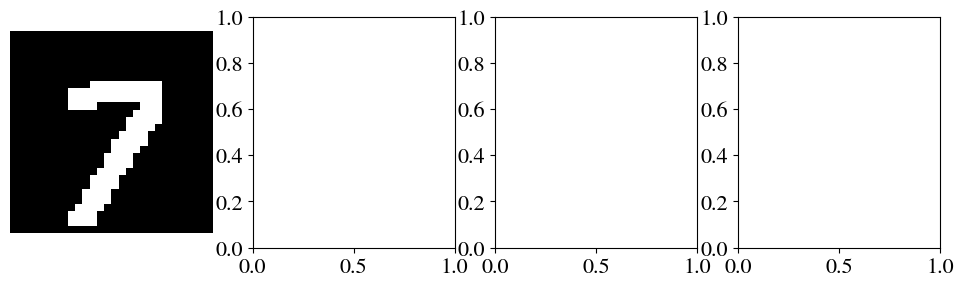

In [18]:
#Visualise a sample
sample_images = get_sample(train_loader)
visualisation.Visualisation().show_samples(sample_images, 4, "Digit Examples")

## Model Components

In [19]:
import torch.nn.functional as F

In [21]:
from torch.nn.functional import relu
import torch.nn as nn
C = 128

class UNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float=0.3):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        print("in_channel", in_channels)

        # Encoder
        # input: 28x28xIN
        self.e11 = nn.Conv2d(in_channels, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe11 = nn.Dropout(p=dropout)
        self.e12 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe12 = nn.Dropout(p=dropout)
        self.e13 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 14x14xC//2

        # input: 14x14xC//2
        self.e21 = nn.Conv2d(C//2, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe21 = nn.Dropout(p=dropout)
        self.e22 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe22 = nn.Dropout(p=dropout)
        self.e23 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 28x28xC
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 7x7xC

        # input: 7x7xC
        self.e31 = nn.Conv2d(C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe31 = nn.Dropout(p=dropout)
        self.e32 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe32 = nn.Dropout(p=dropout)
        self.e33 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7xC

        # Decoder
        # input: 7x7x2*C
        self.upconv1 = nn.ConvTranspose2d(2*C, C, kernel_size=2, stride=2) # output: 14x14xC
        self.d11 = nn.Conv2d(2*C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd11 = nn.Dropout(p=dropout)
        self.d12 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd12 = nn.Dropout(p=dropout)
        self.d13 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC

        # input: 14x14x2*C
        self.upconv2 = nn.ConvTranspose2d(C, C//2, kernel_size=2, stride=2) # output: 28x28x7
        self.d21 = nn.Conv2d(C, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd21 = nn.Dropout(p=dropout)
        self.d22 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd22 = nn.Dropout(p=dropout)
        self.d23 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2

        # Output layer
        # input: 28x28xC//2
        self.outconv = nn.Conv2d(C//2, out_channels, kernel_size=1) # output: 28x28xOUT

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Performs a forward pass on the model.

        Args:
            x (torch.Tensor): input data.

        Returns:
            torch.Tensor: output data.
        """
        # Encode the input data
        xe11 = self.dpe11(relu(self.e11(x)))
        xe12 = self.dpe12(relu(self.e12(xe11)))
        xe13 = relu(self.e13(xe12))
        xp1 = self.pool1(xe11)

        xe21 = self.dpe21(relu(self.e21(xp1)))
        xe22 = self.dpe22(relu(self.e22(xe21)))
        xe23 = relu(self.e23(xe22))
        xp2 = self.pool2(xe23)

        xe31 = self.dpe31(relu(self.e31(xp2)))
        xe32 = self.dpe32(relu(self.e32(xe31)))
        xe33 = relu(self.e33(xe32))

        # Decode the computed encoding
        xu11 = self.upconv1(xe33)
        xu12 = torch.cat([xu11, xe23], dim=1)
        xd11 = self.dpd11(relu(self.d11(xu12)))
        xd12 = self.dpd12(relu(self.d12(xd11)))
        xd13 = relu(self.d13(xd12))

        xu21 = self.upconv2(xd13)
        xu22 = torch.cat([xu21, xe13], dim=1)
        xd21 = self.dpd21(relu(self.d21(xu22)))
        xd22 = self.dpd22(relu(self.d22(xd21)))
        xd23 = relu(self.d23(xd22))

        # Output layer
        out = self.outconv(xd23)
        return out

In [22]:
class BayesianFlowNetwork2D(nn.Module):
    def __init__(self, network, D, K, beta=3.0):
        super(BayesianFlowNetwork2D, self).__init__()
        self.beta = beta
        self.D = D
        self.K = K
        self.network = network

    def forward(self, theta: torch.Tensor, t: torch.Tensor, ema: torch_ema.ExponentialMovingAverage) -> torch.Tensor:
        """
        Performs a forward pass.

        Args:
            theta (torch.Tensor)
            t (torch.Tensor): time factor
            ema (torch_ema.ExponentialMovingAverage): EMA used in the model.

        Returns:
            torch.Tensor
        """
        theta = (theta * 2) - 1  # scaled in [-1, 1]
        theta = torch.transpose(theta, 1, 3)
        if ema is not None:
          with ema.average_parameters():
            output = self.network(theta + t[:, None, None, None])  # (B, D, D, K)
        else:
          output = self.network(theta + t[:, None, None, None])  # (B, D, D, K)
        return torch.transpose(output, 1, 3)

    def discrete_output_distribution(self, theta: torch.Tensor, t: torch.Tensor, ema: torch_ema.ExponentialMovingAverage=None) -> torch.Tensor:
        """
        Computes the discrete output distribution of the model.

        Args:
            theta (torch.Tensor)
            t (torch.Tensor): time factor
            ema (torch_ema.ExponentialMovingAverage, optional): EMA used in the model. Defaults to None.

        Returns:
            torch.Tensor
        """
        # Forward pass
        output = self.forward(theta, t, ema=ema)
        # Compute the output probabilities accordingly
        if self.K == 2:
            p0_1 = torch.sigmoid(output)  # (B, D, D, 1)
            p0_2 = 1 - p0_1
            p0 = torch.cat((p0_1, p0_2), dim=-1)  # (B, D, D, 2)
        else:
            p0 = torch.nn.functional.softmax(output, dim=-1)
        return p0

    def process(self, x: torch.Tensor, time: float=None, training: bool=True) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Performs a step of the process.

        Args:
            x (torch.Tensor): input data.
            time (float, optional): time factor in the process - timestep t In [0, 1]. Defaults to None.
            training (bool, optional): weither it is during training phase or not. Defaults to True.

        Returns:
            torch.Tensor | tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]: if training, only returns the current loss. Otherwise, returns the loss, the generated images, the categorical images and the time factor
        """
        # Step 1: Sample t from U(0, 1) if not provided
        t = torch.tensor(time, device=x.device, dtype=torch.float32)[None] if time else torch.rand((x.size(0),), device=x.device, dtype=torch.float32)
        # Step 2: Calculate Beta
        beta = self.beta * (t ** 2)  # (B,)
        # Step 3: Sample y from N(beta * (K * one_hot(X))
        one_hot_x = F.one_hot(x.permute(0, 2, 3, 1).to(torch.int64), num_classes=self.K).float().squeeze()  # (B, D, D, K)
        mean = beta[:, None, None, None] * (self.K * one_hot_x - 1)
        std = (beta * self.K)[:, None, None, None].sqrt()
        eps = torch.randn_like(mean)
        y = mean + std * eps
        # Step 4: Compute the Theta
        theta = F.softmax(y, dim=-1)
        # Step 5: Calculate the output distribution
        p_0 = self.discrete_output_distribution(theta, t)  # (B, D, D, K)
        e_x = one_hot_x
        e_hat = p_0  # (B, D, D, K)
        L_infinity = self.K * self.beta * t[:, None, None, None] * ((e_x - e_hat) ** 2)
        if training:
          return L_infinity.mean()
        else:
           k = torch.distributions.Categorical(probs=p_0).sample()
           return L_infinity.mean(), y, k, t

    @torch.inference_mode()
    def sample(self, batch_size: int=128, nb_steps: int=10, ema: torch_ema.ExponentialMovingAverage=None, device: str='cpu') -> torch.Tensor:
        self.eval()
        # get prior
        theta = torch.ones((batch_size, self.D, self.D, self.K), device=device) / self.K
        t = torch.zeros((theta.shape[0]), device=theta.device, dtype=theta.dtype)
        for i in tqdm(range(1, nb_steps+1)):
            t = (i-1) / nb_steps
            t = t * torch.ones((theta.shape[0]), device=theta.device, dtype=theta.dtype)
            k_probs = self.discrete_output_distribution(theta, t, ema=ema)  # (B, D, D, K)
            k = torch.distributions.Categorical(probs=k_probs).sample()  # (B, D, D)
            alpha = self.beta * (2 * i - 1) / (nb_steps ** 2)
            e_k = F.one_hot(k, num_classes=self.K).float()  # (B, D, D, K)
            mean = alpha * (self.K * e_k - 1)
            var = (alpha * self.K)
            std = torch.full_like(mean, fill_value=var).sqrt()
            eps = torch.randn_like(e_k)
            y = mean + std * eps  # (B, D, D, K)
            theta_prime = torch.exp(y) * theta
            theta = theta_prime / theta_prime.sum(-1, keepdim=True)
        k_probs_final = self.discrete_output_distribution(theta, torch.ones_like(t), ema=ema)
        k_final = torch.distributions.Categorical(probs=k_probs_final).sample()
        return k_final.cpu().numpy()

# Training

In [23]:

unet = UNet(2, 1, dropout=0.5)
bfn = BayesianFlowNetwork2D(network=unet, D=28, K=2).to(config.device)
ema = torch_ema.ExponentialMovingAverage(bfn.network.parameters(), decay=0.9999)
ema.to(config.device)
optim = AdamW(bfn.parameters(), lr=config.learning_rate, betas=(0.9, 0.98), weight_decay=0.01)

in_channel 2


In [24]:
PATIENCE = 1e6

In [25]:
from math import inf
from accelerate import Accelerator
from huggingface_hub import HfFolder, Repository, whoami
from tqdm.auto import tqdm
import os

accelerator = Accelerator(
    mixed_precision=config.mixed_precision,
    gradient_accumulation_steps=config.gradient_accumulation_steps,
  )

def train_model(model: any, optimizer: any, train_loader) -> list[float]:
  """
  Train a BFN model, given an optimizer.
  """

  losses = []
  best_loss = inf
  k = 0
  global_step = 0
  for epoch in range(5):
    progress_bar = tqdm(total=len(train_loader), disable=not accelerator.is_local_main_process)
    progress_bar.set_description(f"Epoch {epoch}")
    for step, batch in enumerate(train_loader):
        images = batch[0]
        images = images.to(config.device)  # Move images to GPU

        optimizer.zero_grad()

        # Clamp the values in 'images' to be non-negative before passing to process
        images = torch.clamp(images, min=0, max=1)
        #print(images.shape)
        with accelerator.accumulate(model):
          loss = model.process(images)
          loss.backward()
          optimizer.step()
          ema.update()
          losses.append(loss.item())
          if loss.item() < best_loss:
            best_loss = loss.item()
            k = 0
          else:
            k += 1
            if k == PATIENCE:
              k = 0
              stop = True
              print("Patience value has been reached, ending training process.")
              break
        logs = {"loss": loss.detach().item(), "step": global_step}
      
        progress_bar.update(1)
        progress_bar.set_postfix(**logs)
        global_step += 1
  
  print(f"Model trained in {epoch+1} epochs.")
  #save the model
  save_path ="./"
  accelerator.save(model, save_path + "test_model.pt")

  return losses

In [26]:
from accelerate import notebook_launcher

# Define a wrapper function that takes the unpacked arguments and calls train_model with the correct number of arguments
def train_wrapper(config, unet, bfn, optim, train_loader):
    return train_model(bfn, optim, train_loader)  # Pass only bfn and optim to train_model

args = (config, unet, bfn, optim, train_loader)

notebook_launcher(train_wrapper, args, num_processes=1)  # Use the wrapper function


Launching training on one GPU.


Epoch 4: 100%|██████████| 118/118 [04:43<00:00,  2.40s/it, loss=0.554, step=589]

Model trained in 5 epochs.


# Result Visualisation

In this section we visualise the results from the previous training. Following the structure from the previous code, we first visualise examplatory the forward diffusion process and then later on the backward diffusion process.

100%|██████████| 1000/1000 [00:31<00:00, 31.25it/s]


<Figure size 1500x300 with 0 Axes>

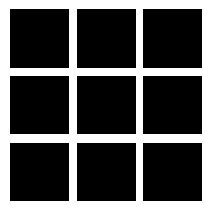

In [27]:
# Visualise the result
images = bfn.sample(device=config.device.type, nb_steps=1000, batch_size=9, ema=ema)
     
visualisation.Visualisation().show_results(images)

steps 10
Visualizing noising process for a single image.


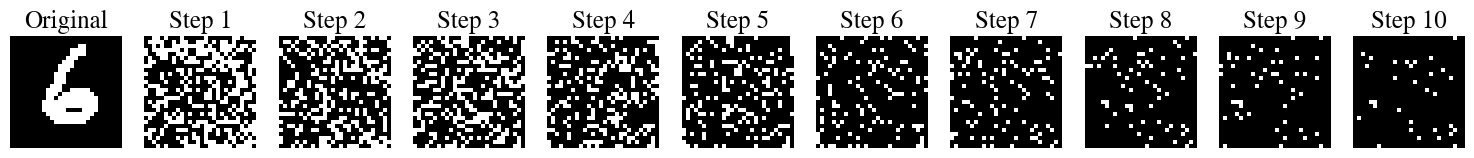

In [28]:
# Fetch the first batch using next()
data_iter = iter(train_loader)
first_batch = next(data_iter)
#prepare the
images = first_batch[0]
images = images.to(config.device)  # Move images to GPU
# Clamp the values in 'images' to be non-negative before passing to process
images = torch.clamp(images, min=0, max=1)
# Set model to evaluation mode
model = bfn.eval()
visualisation.Visualisation().visualize_noising_single_image(model, images[0], nb_steps=10, ema=ema)

100%|██████████| 240/240 [00:03<00:00, 63.33it/s]


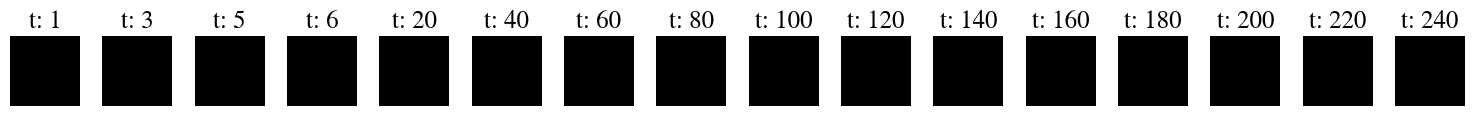

In [29]:
timesteps_to_visualize = [1, 3, 5, 6, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]

# Create a single figure with subplots arranged in a single row
fig, axes = plt.subplots(1, len(timesteps_to_visualize), figsize=(15, 3))

for idx, (ax, timestep) in enumerate(zip(axes, timesteps_to_visualize)):
    images = bfn.sample(device=config.device.type, nb_steps=timestep, batch_size=9, ema=ema)
    
    # Create a 3x3 grid of images for each timestep
    for i in range(9):
        row = i // 3
        col = i % 3
        ax.imshow(images[i], cmap='Greys_r')
        ax.set_title(f"t: {timestep}")
        ax.axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

100%|██████████| 240/240 [00:03<00:00, 63.46it/s]


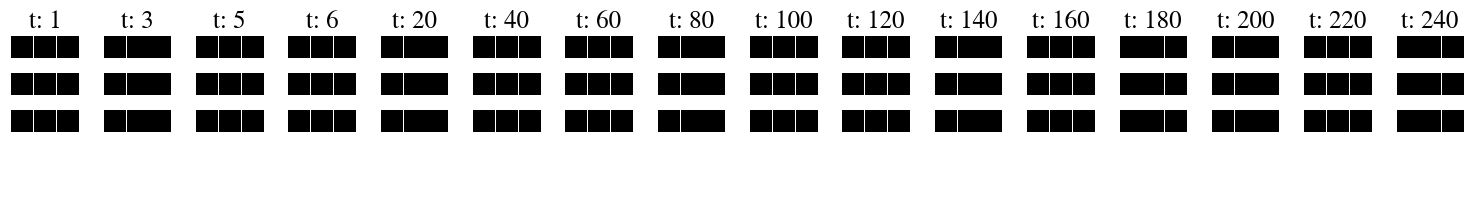

In [30]:
visualisation.Visualisation().visualise_denoising_process(bfn, config, timesteps_to_visualize, ema)